## Clinical Analytics 101 — Milestone 10

This tutorial series teaches **time-series SQL**, **CTEs** and **window
functions** the way analytics happens in a real organisation: someone asks a
*business question*, and you shape the data to answer it.

| Notebook | You will learn | Business questions |
|---|---|---|
| **Beginner** | JOINs, `date_trunc` time buckets, CTEs | Who is on the ward? Build the hourly handoff report. Flag the patient who needs attention at 04:00. |
| **Intermediate** | `LAG`/`LEAD`, moving averages, `RANK`/`NTILE` | When did the deterioration start? Is that spike real or device noise? Where does a reading sit in its patient's distribution? |
| **Advanced** | gap-and-islands episodes, sessionization, truth audits | How many *distinct* episodes? How do hundreds of alarm ticks become 2 alarm events? Can we trust the monitor? |

### How a lesson works

Every lesson is one heavily-commented SQL file in `sql/dql/<tier>/`. In each
lesson you read the business question, **read the SQL file** (it is printed),
**run it against the live Trino lakehouse**, read the answer, and see it on a
chart. With the compose stack down, the lesson cells fall back to the
pre-rendered parquet snapshots in `datasets/m10/lessons/`.

### The dataset

A tiny ward simulated by this repo (5-second telemetry through the Milestone 8
device layer):

| Patient | MRN | Story | Admitted | Monitored |
|---|---|---|---|---|
| **Naomi Brooks** | MRN-000101 | Desaturation (hypoxemia) | 00:00 | 6 h |
| **Cole Freeman** | MRN-000102 | Tachycardia | 00:30 | 5 h |
| **Ivy Watson** | MRN-000103 | Stable control | 01:00 | 3 h |

Patient demographics + admissions live in **MySQL** (`mysql.clinical`), the
observed vitals in the **Iceberg lakehouse** (`lake.lakehouse.vitals`), and
the exact simulated physiology in `lake.lakehouse.vitals_truth` (used in the
advanced notebook). `Ava Chen` and `Marcus Lee` are two legacy patients left
from earlier milestones — a gift, because real databases always contain older,
messier history.

> Rebuild or check this dataset anytime with
> `uv run python scripts/generate_m10_dataset.py`.


In [1]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

from healthcare_timeseries_lab.tutorials import (
    Lesson,
    load_lesson_sql,
    run_lesson,
    run_live,
    ward_names,
)

WARD = ward_names()
NAOMI = "55555555-5555-5555-5555-555555555555"
COLE = "66666666-6666-6666-6666-666666666666"
IVY = "77777777-7777-7777-7777-777777777777"


def lesson(stem: str) -> Lesson:
    tier = {"b": "beginner", "i": "intermediate", "a": "advanced"}[stem[0]]
    return Lesson(tier=tier, stem=stem)


def show_sql(stem: str) -> None:
    print(load_lesson_sql(lesson(stem)))


def tz_free(series: pd.Series) -> pd.Series:
    values = pd.to_datetime(series)
    if values.dt.tz is None:
        values = values.dt.tz_localize("UTC")
    return values.dt.tz_convert("UTC").dt.tz_localize(None)


pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 140)
plt.rcParams["figure.figsize"] = (11, 4.2)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


# Intermediate — spot the turning points

The beginner notebook showed you the *what*: summaries. This one is about the
*when* and the *how much*. Window functions answer three classic questions
about a stream:

1. What happened right before this row? → `LAG`/`LEAD`
2. What is the local trend over a window? → moving averages
3. Where does this row rank in its own history? → `RANK`/`NTILE`

> **The one big idea.** A window function computes a value *per row* over a
> moving set of neighboring rows — unlike `GROUP BY` it does NOT collapse your
> rows. That's why you can still see every 5-second tick *and* its surrounding
> context — and why you can't filter a window inside its own SELECT. You wrap
> it in a CTE (you already know CTEs!).


### I1 — "When did Naomi start to deteriorate?"

Pinpoint the reading where Naomi's SpO2 first crossed **below 94%** after being
at/above it, and show the reading before and after.

*What this teaches:* `LAG(value, 1) OVER (PARTITION BY patient_id ORDER BY
event_time)` reads the *previous row* in the window; a **state transition**
`previous >= 94 AND current < 94` finds the START of an event without an event
table. Change the threshold in the SQL file to `90` and watch the crossing move
toward the deep plateau.


**1. Read the SQL for `i1_first_drop`** — the file comments explain the business question and how the query is assembled, piece by piece.

In [2]:
show_sql("i1_first_drop")

-- ============================================================================
-- Lesson I1 — "Find the moment Naomi started to deteriorate"
--
-- Business question
--   The quality team wants the exact reading where Naomi's desaturation
--   began: the first tick where SpO2 crossed BELOW 94% after being at or
--   above it. Report the reading before and the reading after.
--
-- Concepts taught
--   * LAG(value, 1) OVER (...) -- look at the PREVIOUS row in a window
--   * PARTITION BY patient_id + ORDER BY event_time -- the window definition
--   * A "state transition" read: previous >= threshold AND current <
--     threshold. This is how you find the START of an event in data without
--     an event table -- you will meet the same idea again in the advanced
--     lessons and turn it into episode boundaries.
--
-- Try: raise the threshold to 90 and watch the crossing move later, closer
-- to the deep plateau.
-- =======================================================================

**2. Run it against the lakehouse.**

In [3]:
df = run_lesson(lesson("i1_first_drop"))
display(df)

,event_time,spo2_before,spo2_after
0,2026-01-01 02:33:20.479244+00:00,94.0,93.0
1,2026-01-01 02:33:45.501875+00:00,94.0,93.0
2,2026-01-01 02:33:55.335465+00:00,94.0,93.0
3,2026-01-01 02:34:10.558311+00:00,94.0,93.0
4,2026-01-01 02:34:40.522037+00:00,94.0,93.0
5,2026-01-01 02:35:00.573516+00:00,94.0,93.0
6,2026-01-01 02:35:25.478640+00:00,94.0,92.0
7,2026-01-01 02:35:35.391940+00:00,94.0,93.0
8,2026-01-01 02:35:50.142256+00:00,94.0,93.0
9,2026-01-01 02:36:00.550972+00:00,94.0,93.0


**Reading the result.** The *first* crossing below 94% is at **02:33:20**
(94 → 93). But the table returns 22 such crossings. Why?

The plateau is deep, but the *shoulders* of the desaturation pass right through
the 94% line, and the monitor adds noise (Milestone 8). Each flicker above 94
registers as a new "crossing" — a raw transition query tells you where the
event started, but it **over-counts events**. That's exactly the problem the
advanced notebook's *gap-and-islands* pattern solves.

First, let's see the whole night: (this bonus cell runs **live** against the
lakehouse)


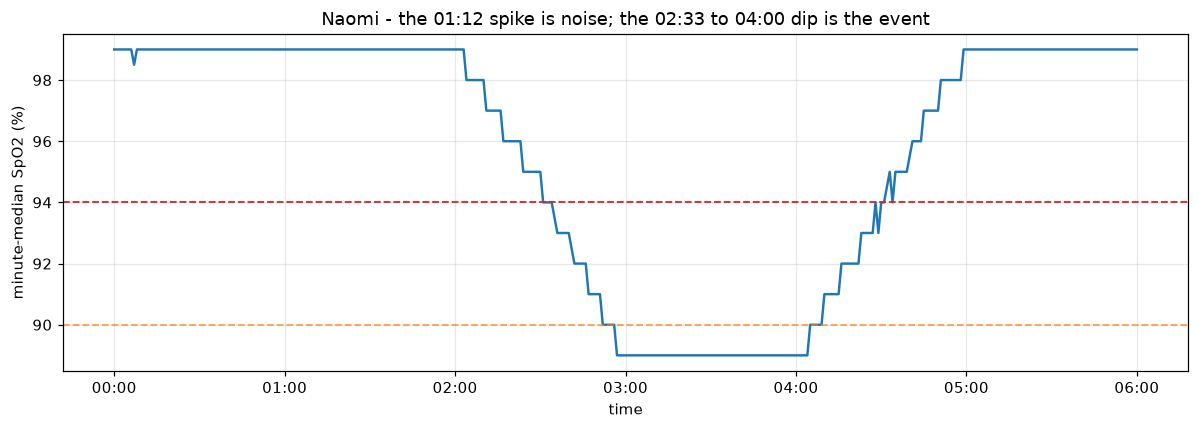

In [4]:
trace = run_live(
    "SELECT event_time, spo2_pct FROM lake.lakehouse.vitals "
    f"WHERE patient_id = '{NAOMI}' ORDER BY event_time"
)
trace["t"] = tz_free(trace["event_time"])
minute = trace.set_index("t")["spo2_pct"].resample("1min").median()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(minute.index, minute.values, color="#1f77b4", lw=1.6)
ax.axhline(94, color="#d62728", ls="--", lw=1.2)
ax.axhline(90, color="#ff7f0e", ls="--", lw=1.2, alpha=0.7)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.set_xlabel("time")
ax.set_ylabel("minute-median SpO2 (%)")
ax.set_title("Naomi - the 01:12 spike is noise; the 02:33 to 04:00 dip is the event")
plt.tight_layout()
plt.show()


In [5]:
big = run_live(
    "WITH d AS ("
    "  SELECT event_time, spo2_pct,"
    "         spo2_pct - LAG(spo2_pct, 1) OVER "
    "           (PARTITION BY patient_id ORDER BY event_time) AS delta"
    "  FROM lake.lakehouse.vitals"
    f"  WHERE patient_id = '{NAOMI}'"
    ") "
    "SELECT event_time, ROUND(delta, 2) AS drop_pct "
    "FROM d WHERE delta IS NOT NULL ORDER BY delta ASC LIMIT 1"
)
display(big)


,event_time,drop_pct
0,2026-01-01 01:11:55.650169+00:00,-3.0


**There's the trap.** The single biggest one-tick drop is **-3.0% at 01:12:45 —
over an hour BEFORE Naomi's real event.** It's a sensor artifact, and
`ORDER BY delta ASC LIMIT 1` confidently reports it as the "worst moment".
Raw extremes in noisy data are nearly always artifacts — which brings us to I2.


### I2 — "Is that spike real, or device noise?"

Compare Naomi's **raw** SpO2 to a **smoothed** line — a centered 7-reading
moving average (≈ ±15 s at a 5 s cadence) — to separate transient spikes from a
genuine sustained trend. Ivy joins as the stable control.

*What this teaches:* a **moving-average window** — `AVG(spo2_pct) OVER (PARTITION
BY patient_id ORDER BY event_time ROWS BETWEEN 3 PRECEDING AND 3 FOLLOWING)`.
Smoothing trades sharpness for stability: spikes vanish, trends survive.


**1. Read the SQL for `i2_moving_average`** — the file comments explain the business question and how the query is assembled, piece by piece.

In [6]:
show_sql("i2_moving_average")

-- ============================================================================
-- Lesson I2 — "Is that reading a real desaturation, or device noise?"
--
-- Business question
--   A spikey reading at 03:15 looks alarming, but the bed is on a monitor
--   with known measurement noise (Milestone 8). We want to compare the RAW
--   reading against a SMOOTHED reading (a centered 7-reading moving average,
--   i.e. roughly +/- 15 seconds at a 5-second cadence) to tell transient
--   spikes apart from sustained trends.
--
-- Concepts taught
--   * Moving-average window: AVG() OVER (PARTITION BY ...
--     ORDER BY ... ROWS BETWEEN n PRECEDING AND n FOLLOWING)
--   * The idea that smoothing trades away sharpness for stability -- in the
--     chart you will SEE spikes appear and vanish in the smoothed line
--   * A paired comparison: for each reading, how far it is from its window
--
-- We compare Naomi (the desaturating patient) against Ivy (the stable
-- control) -- same device profile, ver

**2. Run it against the lakehouse.**

In [7]:
df = run_lesson(lesson("i2_moving_average"))
display(df)

,event_time,full_name,raw_spo2,spo2_ma,deviation_from_average
0,2026-01-01 00:00:05.632024+00:00,Naomi Brooks,99.0,99.0,0.0
1,2026-01-01 00:00:10.521791+00:00,Naomi Brooks,99.0,99.0,0.0
2,2026-01-01 00:00:15.451341+00:00,Naomi Brooks,99.0,99.0,0.0
3,2026-01-01 00:00:20.316592+00:00,Naomi Brooks,99.0,99.0,0.0
4,2026-01-01 00:00:25.614936+00:00,Naomi Brooks,99.0,99.0,0.0
...,...,...,...,...,...
6450,2026-01-01 05:59:40.428495+00:00,Naomi Brooks,99.0,99.0,0.0
6451,2026-01-01 05:59:45.503560+00:00,Naomi Brooks,99.0,99.0,0.0
6452,2026-01-01 05:59:50.491451+00:00,Naomi Brooks,99.0,99.0,0.0
6453,2026-01-01 05:59:55.621704+00:00,Naomi Brooks,99.0,99.0,0.0


**Reading the result.** `deviation_from_average` shows how far each tick sits
from its own local window. On the raw curve Ivy's monitor even reports an
*impossible* **102% SpO2** (noise + rounding) — the smoothing window ages that
artifact out.


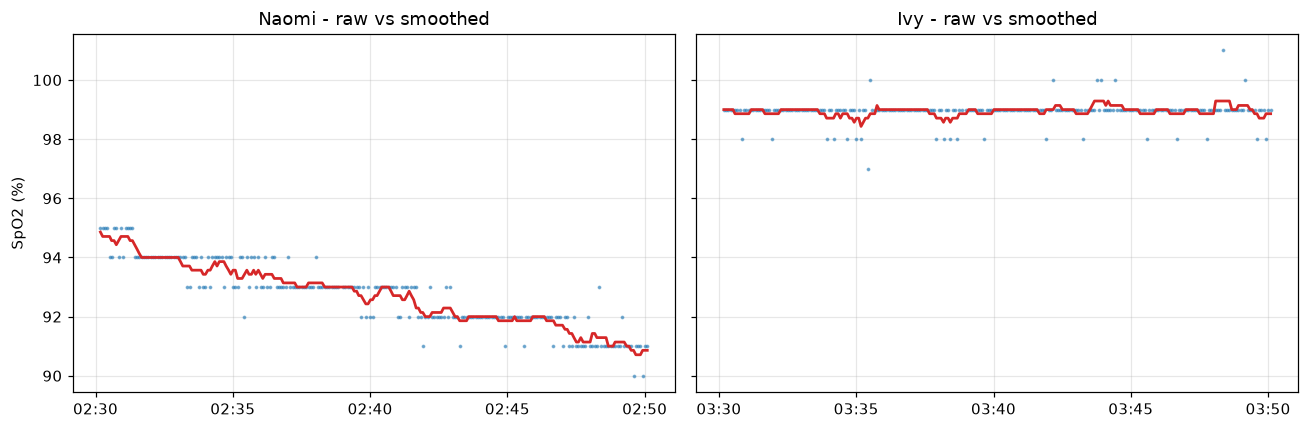

In [8]:
ma = run_lesson(lesson("i2_moving_average")).copy()
ma["t"] = tz_free(ma["event_time"])

fig, (ax_n, ax_i) = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for axis, patient, label in (
    (ax_n, "Naomi Brooks", "Naomi"),
    (ax_i, "Ivy Watson", "Ivy"),
):
    one = ma[ma["full_name"] == patient].sort_values("t")
    window_start = one["t"].min() + pd.Timedelta(hours=2, minutes=30)
    window_end = window_start + pd.Timedelta(minutes=20)
    seg = one[(one["t"] >= window_start) & (one["t"] < window_end)]
    axis.plot(seg["t"], seg["raw_spo2"], ".", color="#1f77b4", ms=3, alpha=0.5)
    axis.plot(seg["t"], seg["spo2_ma"], color="#d62728", lw=1.8)
    axis.set_title(f"{label} - raw vs smoothed")
    axis.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax_n.set_ylabel("SpO2 (%)")
plt.tight_layout()
plt.show()


In [9]:
counts = run_live(
    "WITH m AS ("
    "  SELECT spo2_pct,"
    "         AVG(spo2_pct) OVER (PARTITION BY patient_id ORDER BY event_time "
    "           ROWS BETWEEN 3 PRECEDING AND 3 FOLLOWING) AS spo2_ma"
    "  FROM lake.lakehouse.vitals"
    f"  WHERE patient_id = '{NAOMI}') "
    "SELECT"
    "  SUM(CASE WHEN spo2_pct < 94 THEN 1 ELSE 0 END) AS raw_below_94,"
    "  SUM(CASE WHEN spo2_ma  < 94 THEN 1 ELSE 0 END) AS smoothed_below_94"
    " FROM m"
)
display(counts)


,raw_below_94,smoothed_below_94
0,1354,1407


**The payoff.** A raw reading dips below 94% **hundreds** of times as noise
re-crosses the line; the 7-reading moving average crosses it only a **handful**
of times near the actual event. That's why smoothing exists: it answers "is
there a *sustained* problem here?" without tuning the alarm to every twitch.

### I3 — "Where does a reading sit in its patient's distribution?"

Label every reading with where it falls in **that patient's own** SpO2
distribution: its worst-rank (1 = the lowest reading of the stay) and its
decile (1 = worst 10%).

*What this teaches:* `RANK()` (ties share a rank — the lowest readings may be a
whole *set* of equal values), `NTILE(10)` (ten equal slices), and the
CTE-wrap rule — you can't filter `RANK()` inside its own SELECT.


**1. Read the SQL for `i3_worst_ranked`** — the file comments explain the business question and how the query is assembled, piece by piece.

In [10]:
show_sql("i3_worst_ranked")

-- ============================================================================
-- Lesson I3 — "Where does every reading sit in its patient's distribution?"
--
-- Business question
--   Risk managers want to label EVERY SpO2 reading of the ward patients with
--   where it falls in that patient's OWN reading distribution: its worst-rank
--   (1 = the single lowest reading of the stay) and its decile.
--
-- Concepts taught
--   * RANK() vs ROW_NUMBER(): two equal readings get the SAME rank (think
--     of tied sports scores), row numbers never repeat
--   * NTILE(n): cut the patient's readings into n equal-sized buckets and
--     label each reading 1..n (1 = worst decile)
--   * The WHERE on window results is done OUTSIDE the window -- you cannot
--     filter ROW_NUMBER() or NTILE() inside their own SELECT -- so we wrap
--     the query in a CTE and filter there
--
-- Why this matters: a reading looks scary in raw numbers, but "this was in
-- Naomi's worst 2%" says something much stro

**2. Run it against the lakehouse.**

In [11]:
df = run_lesson(lesson("i3_worst_ranked"))
display(df)

,full_name,spo2,event_time,spo2_worst_rank,spo2_decile
0,Cole Freeman,95.0,2026-01-01 03:05:25.478640+00:00,1,1
1,Cole Freeman,95.0,2026-01-01 03:11:55.106584+00:00,1,1
2,Cole Freeman,95.0,2026-01-01 02:54:00.199210+00:00,1,1
3,Cole Freeman,95.0,2026-01-01 04:14:10.474362+00:00,1,1
4,Cole Freeman,95.0,2026-01-01 01:50:25.430779+00:00,1,1
5,Ivy Watson,97.0,2026-01-01 02:20:25.430779+00:00,1,1
6,Ivy Watson,97.0,2026-01-01 03:35:25.478640+00:00,1,1
7,Ivy Watson,97.0,2026-01-01 03:24:00.199210+00:00,1,1
8,Naomi Brooks,87.0,2026-01-01 03:44:10.474362+00:00,1,1
9,Naomi Brooks,88.0,2026-01-01 03:58:30.833210+00:00,2,1


**Reading the result.** The three worst readings per patient:

* Naomi's worst cluster around **88-89** — and with ~430 readings in *every*
  decile, her worst decile is hundreds of ticks. A reading of 89 isn't just
  low in absolute terms; it's in Naomi's **own worst few percent**.
* Cole and Ivy's "worst three" are ~95-97 and 99 — for healthy patients their
  personal worst is still clinically fine. Ranking against the *patient's own*
  distribution turns a raw number into a personalized flag.


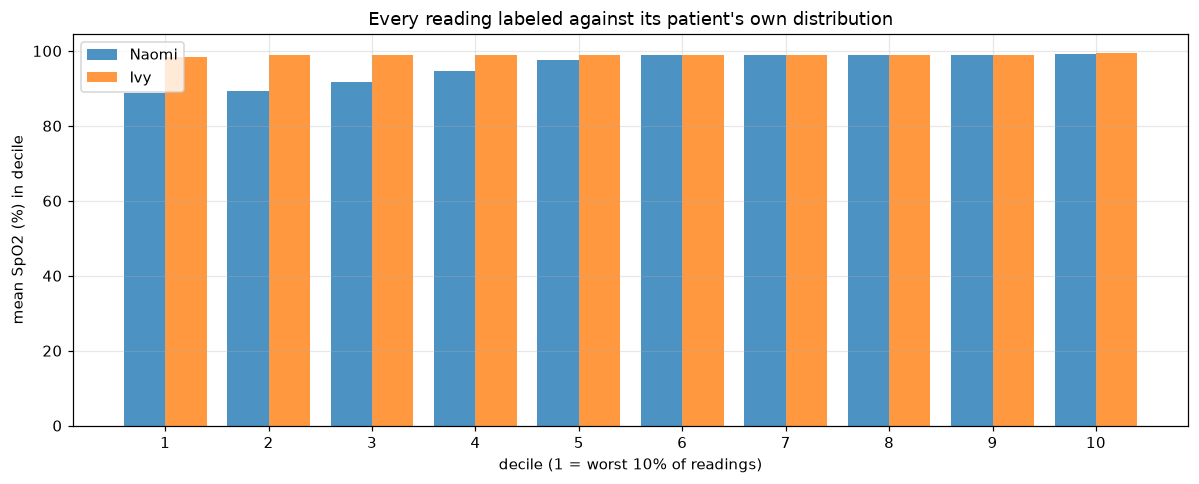

In [12]:
deciles = run_live(
    "WITH dist AS ("
    "  SELECT patient_id, spo2_pct,"
    "         NTILE(10) OVER (PARTITION BY patient_id ORDER BY spo2_pct ASC) AS d"
    "  FROM lake.lakehouse.vitals"
    f"  WHERE patient_id IN ('{NAOMI}', '{IVY}')) "
    " SELECT patient_id, d, ROUND(AVG(spo2_pct), 1) AS mean_spo2, COUNT(*) AS n"
    " FROM dist GROUP BY 1, 2 ORDER BY 1, 2"
)
deciles["name"] = deciles["patient_id"].map(WARD)

fig, ax = plt.subplots(figsize=(11, 4.5))
for offset, name in ((-0.2, "Naomi Brooks"), (0.2, "Ivy Watson")):
    one = deciles[deciles["name"] == name].sort_values("d")
    ax.bar(one["d"] + offset, one["mean_spo2"], width=0.4, alpha=0.8, label=name.split()[0])
ax.set_xticks(range(1, 11))
ax.set_xlabel("decile (1 = worst 10% of readings)")
ax.set_ylabel("mean SpO2 (%) in decile")
ax.set_title("Every reading labeled against its patient's own distribution")
ax.legend()
plt.tight_layout()
plt.show()


**Your turn.**

1. In `i1_first_drop.sql` change the threshold from `94` to `90` — the first
   crossing moves to ~02:54 and the transition count collapses. Thresholds
   change the number of "events" you see.
2. In `i2_moving_average.sql` change the window to `ROWS BETWEEN 9 PRECEDING
   AND 9 FOLLOWING`. The line gets smoother — and slower to react. That lag is
   the price of calm.
3. In `i3_worst_ranked.sql` switch `RANK()` to `DENSE_RANK()` and diff the two
   worst lists. When your values are repeated, dense ranks behave differently.

## End of the intermediate course

You can now see time: `LAG`/`LEAD` give you before/after, moving averages give
you sustained trends, and `RANK`/`NTILE` give you personalized flags. The
advanced notebook turns these primitives into episodes, alarms and an audit.
